# Figure 1

In [3]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd
import os

In [4]:
## Read in IRWin Station Data
from pathlib import Path, PurePath
SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')

PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)

irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])

irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

In [6]:
# MODELED
save_dir = 'modeled-station-data'

s3_dsw3 = xr.open_dataset(os.path.join(save_dir, 's3_dsw3.nc'))
s3_dsw1 = xr.open_dataset(os.path.join(save_dir, 's3_dsw1.nc'))
s3_dsw30 = xr.open_dataset(os.path.join(save_dir, 's3_dsw30.nc'))
s3_k = xr.open_dataset(os.path.join(save_dir, 's3_k.nc'))
s3_ghi = xr.open_dataset(os.path.join(save_dir, 's3_ghi.nc'))

m1_dsw3 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw3.nc'))
m1_dsw1 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw1.nc'))
m1_dsw30 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw30.nc'))
m1_k = xr.open_dataset(os.path.join(save_dir, 'm1_k.nc'))
m1_ghi = xr.open_dataset(os.path.join(save_dir, 'm1_ghi.nc'))

irwin_dsw3 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw3.nc'))
irwin_dsw30 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw30.nc'))
irwin_dsw1 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw1.nc'))
irwin_k = xr.open_dataset(os.path.join(save_dir, 'irwin_k.nc'))
irwin_ghi = xr.open_dataset(os.path.join(save_dir, 'irwin_ghi.nc'))

sos_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw3.nc'))
sos_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw1.nc'))
sos_dsw30 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw30.nc'))
sos_k = xr.open_dataset(os.path.join(save_dir, 'sos_k.nc'))
sos_ghi = xr.open_dataset(os.path.join(save_dir, 'sos_ghi.nc'))

# # # # # # #

# STATION DATA
save_dir = 'station-data'

# SAIL M1 QCRAD LONG
m1_sail_swqc = xr.open_dataset(os.path.join(save_dir, 'm1qc_sw.nc'))
m1_sail_bestqc = xr.open_dataset(os.path.join(save_dir, 'm1qc_best_sw.nc'))


subset_dif_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_diff.nc'))
subset_dir_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dir.nc'))
subset_zenith_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_zen.nc'))
sub_dirh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dirh.nc'))
sub_difh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_difh_xx.nc'))

# SAIL M1 & S3
m1_sail = xr.open_dataset(os.path.join(save_dir, 'm1_sw.nc'))
s3_sail = xr.open_dataset(os.path.join(save_dir, 's3_sw.nc'))

# SOS
sos_path = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/hourlyAvg_radiation_uw.nc'
ds = xr.open_dataset(sos_path)

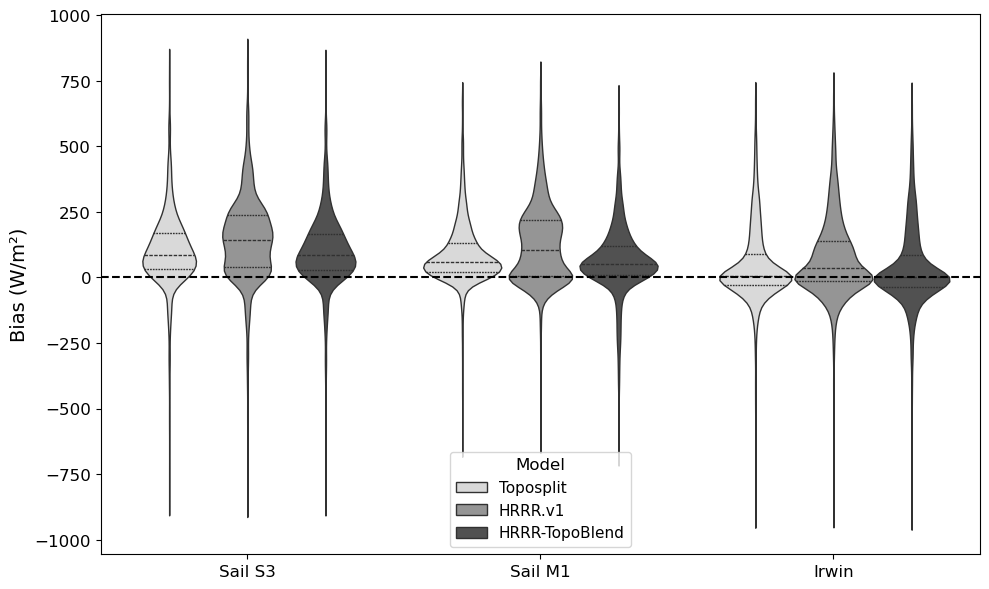

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time range
start_wy2022 = '2021-10-01'
end_wy2022 = '2022-06-25'

# --- Helper function to calculate bias ---
def compute_bias(obs, model):
    obs = obs.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs = obs[obs > 0]
    model = model.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs, model = xr.align(obs, model)
    return (model - obs).to_series()

# --- S3 ---
s3_obs = s3_sail['down_short_hemisp'].clip(min=0)
s3_bias_3 = compute_bias(s3_obs, s3_dsw3['dsw3h']).rename('Sail S3')
s3_bias_1 = compute_bias(s3_obs, s3_dsw1['dsw1']).rename('Sail S3')
s3_model_b = s3_dsw30['dsw3'] - (s3_dsw1['dsw1'] - s3_dsw3['dsw3h'])
s3_bias_b = compute_bias(s3_obs, s3_model_b).rename('Sail S3')

# --- M1 ---
m1_obs = m1_sail['down_short_hemisp']
m1_bias_3 = compute_bias(m1_obs, m1_dsw3['dsw3h']).rename('Sail M1')
m1_bias_1 = compute_bias(m1_obs, m1_dsw1['dsw1']).rename('Sail M1')
m1_model_b = m1_dsw30['dsw3'] - (m1_dsw1['dsw1'] - m1_dsw3['dsw3h'])
m1_bias_b = compute_bias(m1_obs, m1_model_b).rename('Sail M1')

# --- Irwin ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model_3 = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()
irwin_model_1 = irwin_dsw1['dsw1'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()
irwin_model_b = (irwin_dsw30['dsw3'] - (irwin_dsw1['dsw1'] - irwin_dsw3['dsw3h'])).sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()

irwin_bias_3 = (irwin_model_3 - irwin_obs).dropna().rename('Irwin')
irwin_bias_1 = (irwin_model_1 - irwin_obs).dropna().rename('Irwin')
irwin_bias_b = (irwin_model_b - irwin_obs).dropna().rename('Irwin')

# --- Combine all bias data ---
def prepare_bias_df(bias_series, model_name):
    df = bias_series.reset_index()
    df.columns = ['Time', 'Bias']
    df['Station'] = bias_series.name  # Use the name of the Series for station
    df['Model'] = model_name
    return df

bias_all = pd.concat([
    prepare_bias_df(s3_bias_3, 'Toposplit'),
    prepare_bias_df(s3_bias_1, 'HRRR.v1'),
    prepare_bias_df(s3_bias_b, 'HRRR-TopoBlend'),

    prepare_bias_df(m1_bias_3, 'Toposplit'),
    prepare_bias_df(m1_bias_1, 'HRRR.v1'),
    prepare_bias_df(m1_bias_b, 'HRRR-TopoBlend'),

    prepare_bias_df(irwin_bias_3, 'Toposplit'),
    prepare_bias_df(irwin_bias_1, 'HRRR.v1'),
    prepare_bias_df(irwin_bias_b, 'HRRR-TopoBlend')
])

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(data=bias_all, x='Station', y='Bias', hue='Model',
               split=False, inner='quartile', palette='Greys', linewidth=1)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Model', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()


In [8]:
m1_sail_bestqc

<xarray.Dataset> Size: 188kB
Dimensions:                         (time: 15672)
Coordinates:
  * time                            (time) datetime64[ns] 125kB 2021-09-01 .....
Data variables:
    BestEstimate_down_short_hemisp  (time) float32 63kB ...

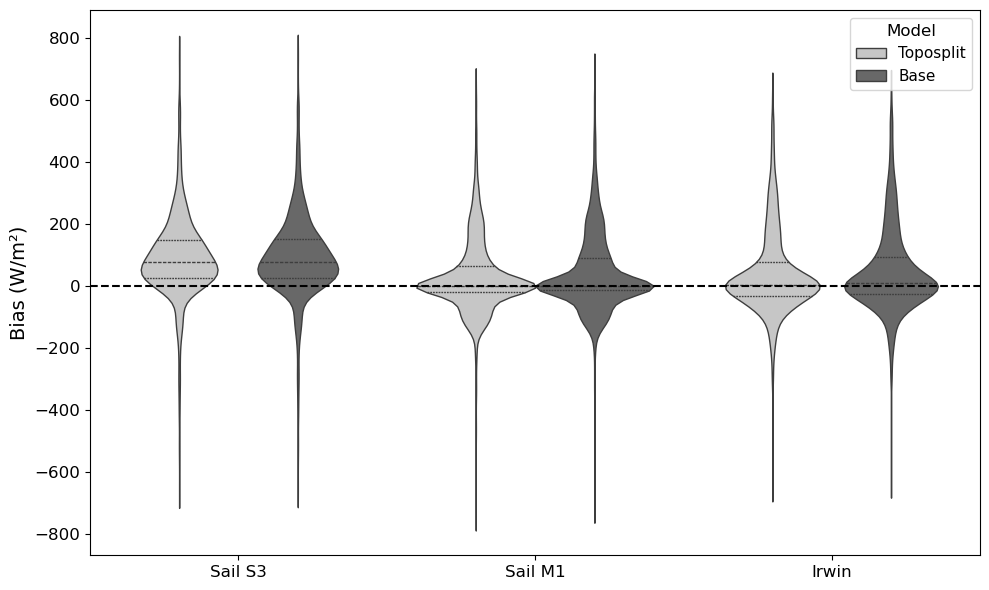

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time range
start_wy2022 = '2021-12-01'
end_wy2022 = '2022-05-01'

# --- Helper function to calculate bias ---
def compute_bias(obs, model):
    obs = obs.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs = obs[obs > 0]
    model = model.sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean()
    obs, model = xr.align(obs, model)
    return (model - obs).to_series()

# --- S3 ---
s3_obs = s3_sail['down_short_hemisp'].clip(min=0)
s3_bias_3 = compute_bias(s3_obs, s3_dsw3['dsw3h']).rename('Sail S3')
s3_bias_b = compute_bias(s3_obs, s3_ghi['ghi']).rename('Sail S3')

# --- M1 ---
m1_obs = m1_sail_bestqc['BestEstimate_down_short_hemisp']
m1_bias_3 = compute_bias(m1_obs, m1_dsw3['dsw3h']).rename('Sail M1')
m1_bias_b = compute_bias(m1_obs, m1_ghi['ghi']).rename('Sail M1')

# --- Irwin ---
irwin_obs = irwin_pyra['VIS_IN'].resample('1h').mean().loc[start_wy2022:end_wy2022]
irwin_obs = irwin_obs[irwin_obs > 0]
irwin_model_3 = irwin_dsw3['dsw3h'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()
irwin_model_b = irwin_ghi['ghi'].sel(time=slice(start_wy2022, end_wy2022)).resample(time='1h').mean().to_series()

irwin_bias_3 = (irwin_model_3 - irwin_obs).dropna().rename('Irwin')
irwin_bias_1 = (irwin_model_1 - irwin_obs).dropna().rename('Irwin')
irwin_bias_b = (irwin_model_b - irwin_obs).dropna().rename('Irwin')

# --- Combine all bias data ---
def prepare_bias_df(bias_series, model_name):
    df = bias_series.reset_index()
    df.columns = ['Time', 'Bias']
    df['Station'] = bias_series.name  # Use the name of the Series for station
    df['Model'] = model_name
    return df

bias_all = pd.concat([
    prepare_bias_df(s3_bias_3, 'Toposplit'),
    prepare_bias_df(s3_bias_b, 'Base'),

    prepare_bias_df(m1_bias_3, 'Toposplit'),
    prepare_bias_df(m1_bias_b, 'Base'),

    prepare_bias_df(irwin_bias_3, 'Toposplit'),
    prepare_bias_df(irwin_bias_b, 'Base')
])

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(data=bias_all, x='Station', y='Bias', hue='Model',
               split=False, inner='quartile', palette='Greys', linewidth=1)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xlabel('')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Model', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()


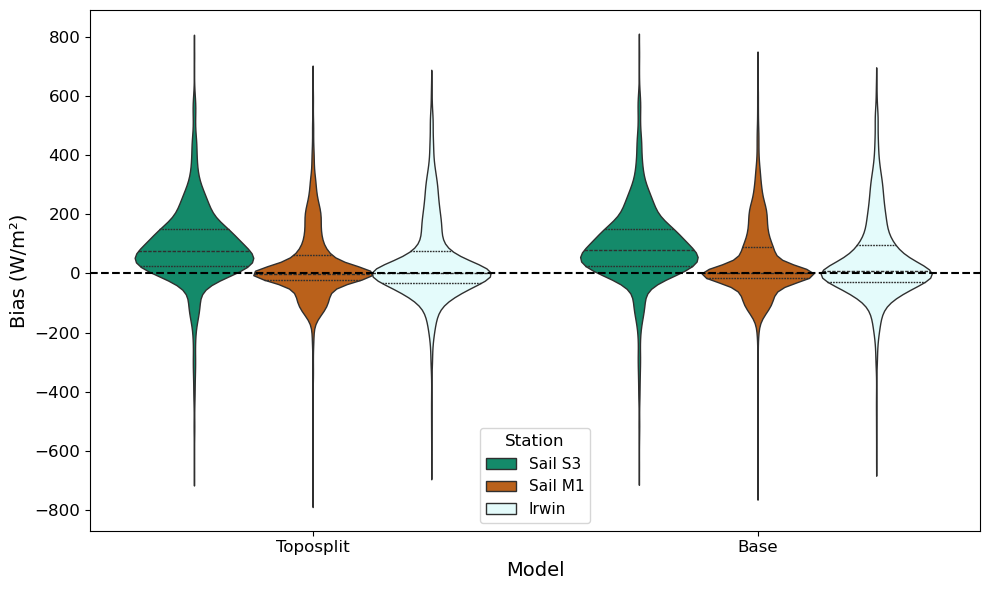

In [15]:
# --- Plot with Model on x-axis and Station as hue ---
plt.figure(figsize=(10, 6))

# Define custom color palette
station_palette = {
    'Sail S3': '#009E73',  # Greenish
    'Irwin': 'lightcyan',
    # 'SOS' : '#56B4E9',    # Blueish
    'Sail M1': '#D55E00'   # Orangish
}

sns.violinplot(
    data=bias_all,
    x='Model', y='Bias', hue='Station',
    split=False, inner='quartile',
    palette=station_palette, linewidth=1
)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Bias (W/m²)', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Station', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()
